# Introduction

This notebook is dedicated to fitting experimental Ramsey data using a Master equation that incorporates both magnetic and electric noise. The decay observed in the data typically follows the form $(1/T_2^*)^{exponent}$. The goal is to find both values for $T_2^*$ and the $exponent$ for electric and magnetic noise. By modeling this decay, we can gain insights into the underlying noise processes affecting the system.

# Imports

In [7]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
from lmfit import Model, Parameters, minimize
import matplotlib.pyplot as plt
import qcodes as qc
import qutip as qt
import lmfit as lm
from spin import Spin
from operations import subspace_rotation_operator
from fit_toolbox import ExponentialSineFit, ExponentialFit


## helper functions

In [26]:
# def ExponentialSineFit(t, amplitude, frequency, phase_offset, tau, alpha, offset):
#     """Exponential decay envelope multiplied by a sine wave.

#     Parameters
#     ----------
#     t : array_like
#         Time values.
#     amplitude : float
#         Amplitude of the sine component.
#     frequency : float
#         Frequency of the sine component (Hz).
#     phase_offset : float
#         Phase offset of the sine component (radians).
#     tau : float
#         Decay time constant.
#     alpha : float
#         Stretch exponent for the decay envelope.
#     offset : float
#         DC offset.
#     """
#     return amplitude * np.sin(2 * np.pi * frequency * t + phase_offset) * np.exp(-(t / tau)**alpha) + offset


# def exponential(x, a, T2, exp, c):
#     return a * np.exp(-(x / T2)**exp) + c

# exp_model = lm.Model(Exponential)
# initial_params = lm.Parameters()
# initial_params.add('a', value=0.5, min=0.4, max=0.6)
# initial_params.add('T2', value=50e-3, min=1e-3, max=600e-3)
# initial_params.add('c', value=0.5, min=0.4, max=0.6)
# initial_params.add('exp', value=1.5, min=0.5, max=2.5)

# Build model

This section sets up the model parameters and prepares the data for fitting. 

In [27]:
nucleus = Spin(I=7/2)
Ix, Iy, Iz = nucleus.get_spin_operators()

In [28]:
def get_cops_sb_qudit(T2_star_m=150e-3, T2_star_e=800e-3, exponent_m=1.6, exponent_e=1.2):
    """Build time-dependent collapse operators for magnetic (Iz) and electric (Iz^2) dephasing.

    The noise profile follows a stretched-exponential (power-law) form so that the collapse
    operator amplitude at time t scales as sqrt(rate) * t^((alpha-1)/2), reproducing a
    exp(-(t/T2*)^alpha) envelope for the coherence.

    Parameters
    ----------
    T2_star_m : float
        Characteristic dephasing time for magnetic (Iz) noise.
    T2_star_e : float
        Characteristic dephasing time for electric (Iz^2) noise.
    exponent_m : float
        Stretch exponent for magnetic noise.
    exponent_e : float
        Stretch exponent for electric noise.

    Returns
    -------
    list
        QuTiP time-dependent collapse operator list suitable for mesolve.
    """
    magnetic_decay_rate = (2 / T2_star_m)**exponent_m
    electric_decay_rate = (2 / T2_star_e)**exponent_e

    def electric_noise_profile(t, args):
        return np.sqrt(electric_decay_rate) * t**((exponent_e - 1) / 2)

    def magnetic_noise_profile(t, args):
        return np.sqrt(magnetic_decay_rate) * t**((exponent_m - 1) / 2)

    c_ops = [[Iz, magnetic_noise_profile], [Iz*Iz, electric_noise_profile]]
    return c_ops

# Static Hamiltonian: zero (working in the generalised rotating frame)
H0 = Iz*0

def fidelity_decay(psi0s, times, c_ops):
    fidelity = np.zeros([len(psi0s), len(times)], dtype=float)
    T2s = np.zeros(len(psi0s))
    alphas = np.zeros(len(psi0s))
    for p, psi0 in enumerate(psi0s):
        result = qt.mesolve(H0, psi0, times, c_ops, options=qt.Options(nsteps=200000))
        exp_res = qt.expect(psi0 * psi0.dag(), result.states)  # overlap with initial state
        fidelity[p] = exp_res
        result = ExponentialFit(fidelity[p], xvals=times)
        T2s[p] = result.params['T2']
        alphas[p] = result.params['exp']
    return fidelity, T2s, alphas

def plot_free_decay(fidelity, T2s):
    kw = {'wspace': 0.4}
    fig, ax = plt.subplots(1, 2, figsize=(8, 2.5), dpi=300, gridspec_kw=kw)
    pcm = ax[0].pcolor(times * 1e3, np.arange(len(fidelity)), fidelity)
    ax[0].set_xlabel('time (ms)')
    ax[0].set_ylabel('Transition index')
    plt.colorbar(pcm, ax=ax[0], label=r'$\langle \psi_0 | \rho | \psi_0 \rangle$')

    for t in range(len(T2s)):
        ax[0].plot([T2s[t] * 1e3, T2s[t] * 1e3], [t - 0.4, t + 0.4], '-', color='tab:red')

    ax[1].plot(np.arange(len(fidelity)), T2s * 1e3, '.', label='Sim', zorder=10)
    ax[1].set_ylim([0, tmax * 1e3])
    ax[1].legend()
    ax[1].set_ylabel('Dephasing time (ms)')
    ax[1].set_xlabel('Transition index')

In [25]:
# initial state - all qubit superpositions states
exponent_e = 1.2
exponent_m = 1.60449971294319
T2_star_m = 200e-3
T2_star_e = 500e-3
c_ops = get_cops_sb_qudit(T2_star_m, T2_star_e, exponent_m, exponent_e)

# m=1 ramsey (free decay)

In [23]:
dt = 2e-3                     # sampling period 20ms
tmax = 500e-3                 # total time perform experiment,
times = np.arange(0,tmax,dt)
psi0s = []
for i in range(7):
    psi0s.append((qt.basis(8, i) + qt.basis(8, i+1)).unit())

fidelity, T2s, alphas = fidelity_decay(psi0s, times, c_ops)

AssertionError: Please provide xvals

In [ ]:
T2s_data = np.array([27.77, 37.79, 80.18, 167.17, 85.43, 51.09, 28.37]) * 1e-3  # experimental T2* values
T2s_err = np.array([0.00235, 0.002821, 0.00605, 0.0603, 0.00664, 0.00298, 0.00405])

plot_free_decay(fidelity, T2s)

# z-cat states

In [596]:
psi0s = [(qt.basis(8, 3) + qt.basis(8, 4)).unit(),
         (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
         (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
         (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
]

In [597]:
fidelity = np.zeros([len(psi0s), len(times)], dtype=float)
T2s = np.zeros(len(psi0s))

fidelity, T2s, alphas = run_free_decay(psi0s, times, c_ops)

Text(0.5, 1.0, 'z-cat')

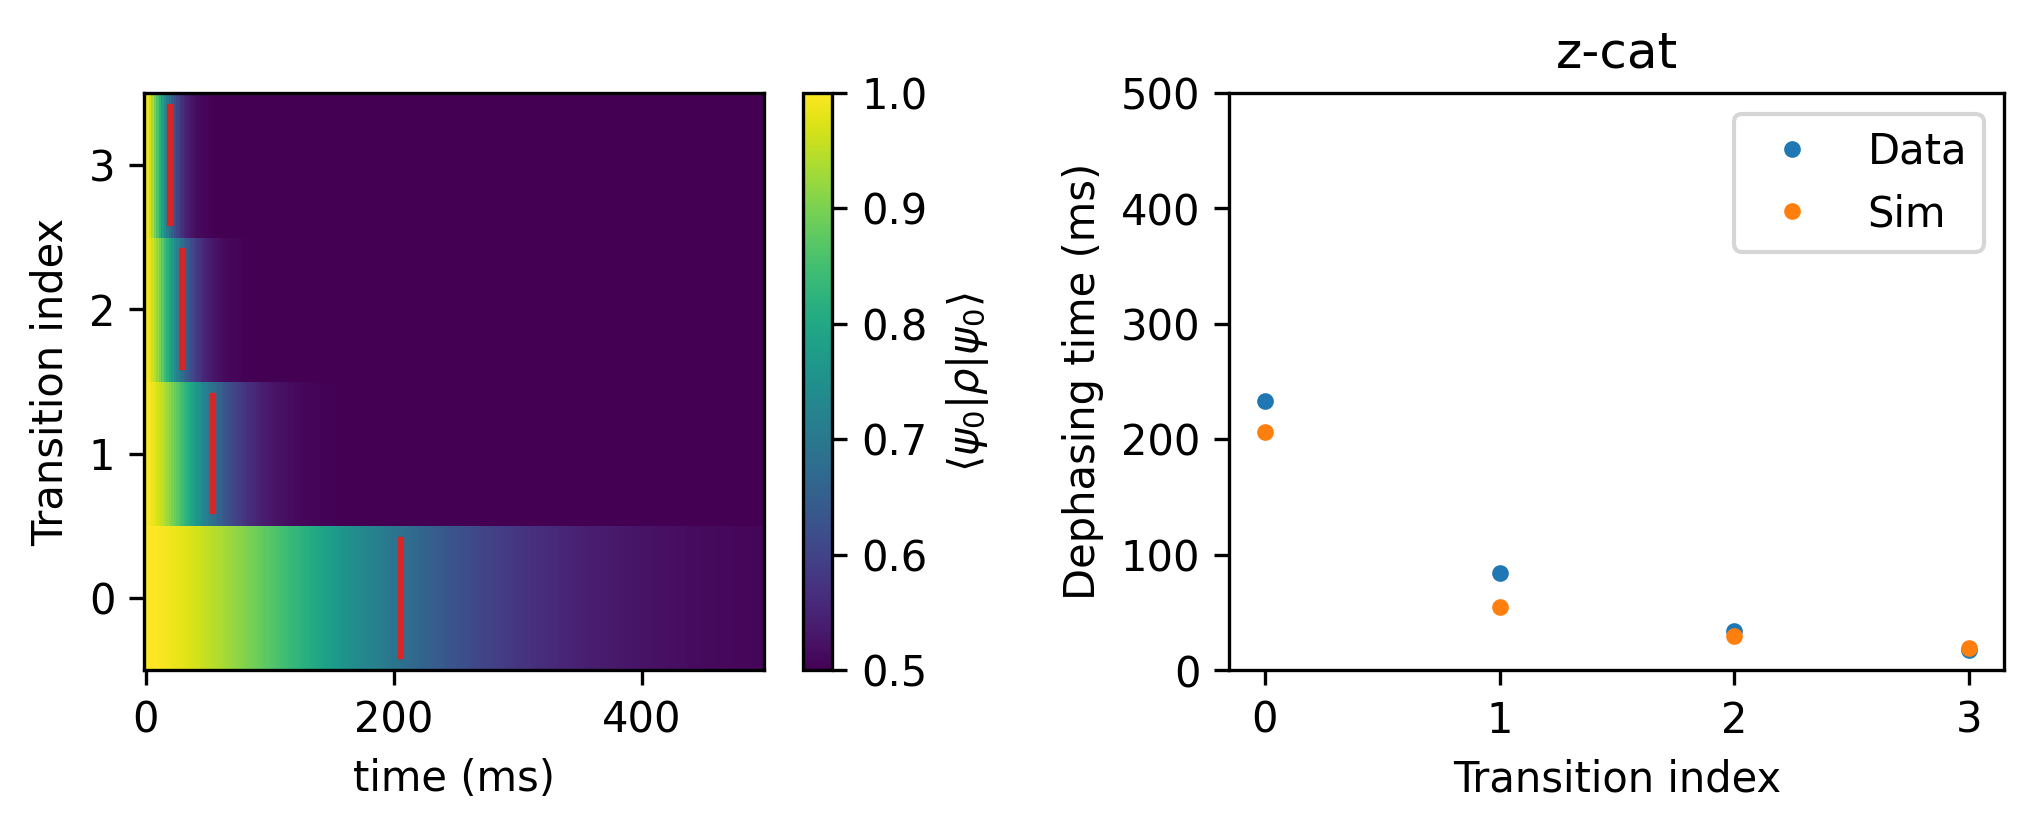

In [598]:
T2s_zdata = np.flip(np.array([17.7, 33.5, 83.7, 233]))*1e-3

plot_free_decay(T2s_zdata, fidelity, T2s)
plt.title('z-cat')

# x-cat states

In [ ]:
# initial states rotated into the x-basis via a pi/2 rotation around y
ny = np.array([0, 1, 0])
nx = np.array([1, 0, 0])
psi0s = [
    qt.Qobj(subspace_rotation_operator(1/2, np.pi/2, ny)) * (qt.basis(8, 3) + qt.basis(8, 4)).unit(),
    qt.Qobj(subspace_rotation_operator(3/2, np.pi/2, ny)) * (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
    qt.Qobj(subspace_rotation_operator(5/2, np.pi/2, ny)) * (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
    qt.Qobj(subspace_rotation_operator(7/2, np.pi/2, ny)) * (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
]

In [865]:
fidelity = np.zeros([len(psi0s), len(times)], dtype=float)
T2s = np.zeros(len(psi0s))

fidelity, T2s, alphas = run_free_decay(psi0s, times, c_ops)

Text(0.5, 1.0, 'x-cat')

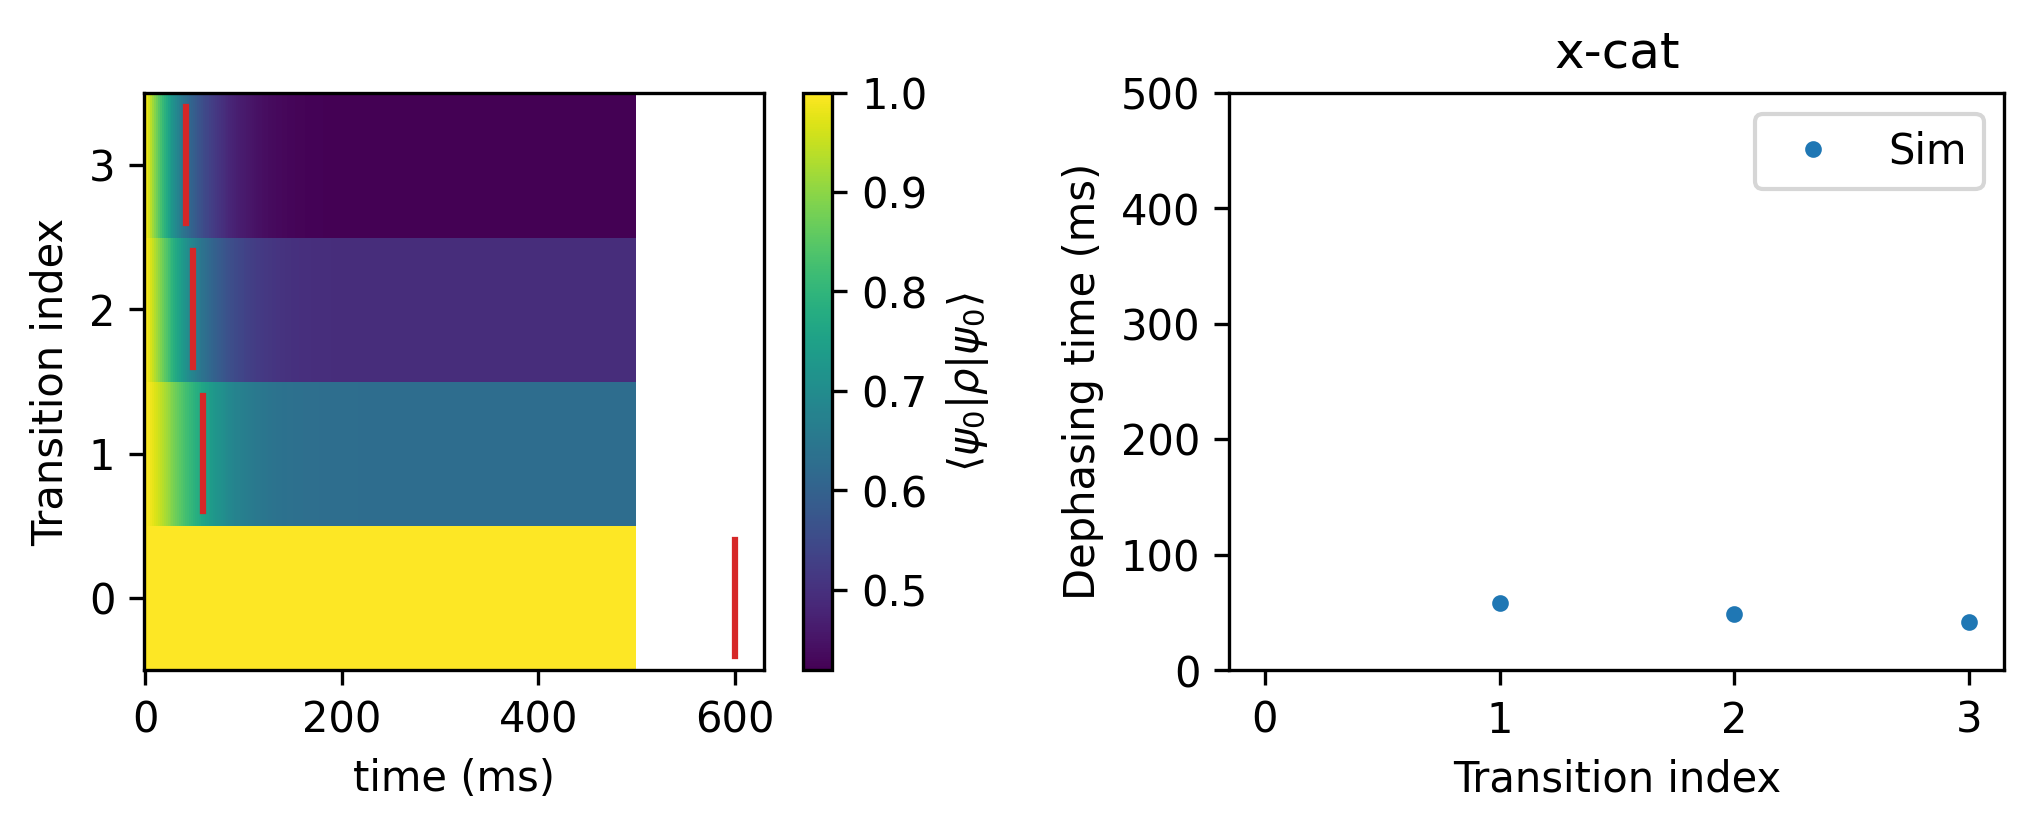

In [866]:
T2s_xdata = np.flip(np.array([46.19, 107.7, 150.8, 233]))*1e-3

plot_free_decay(fidelity, T2s)
plt.title('x-cat')

Text(0.5, 1.0, 'x-cat')

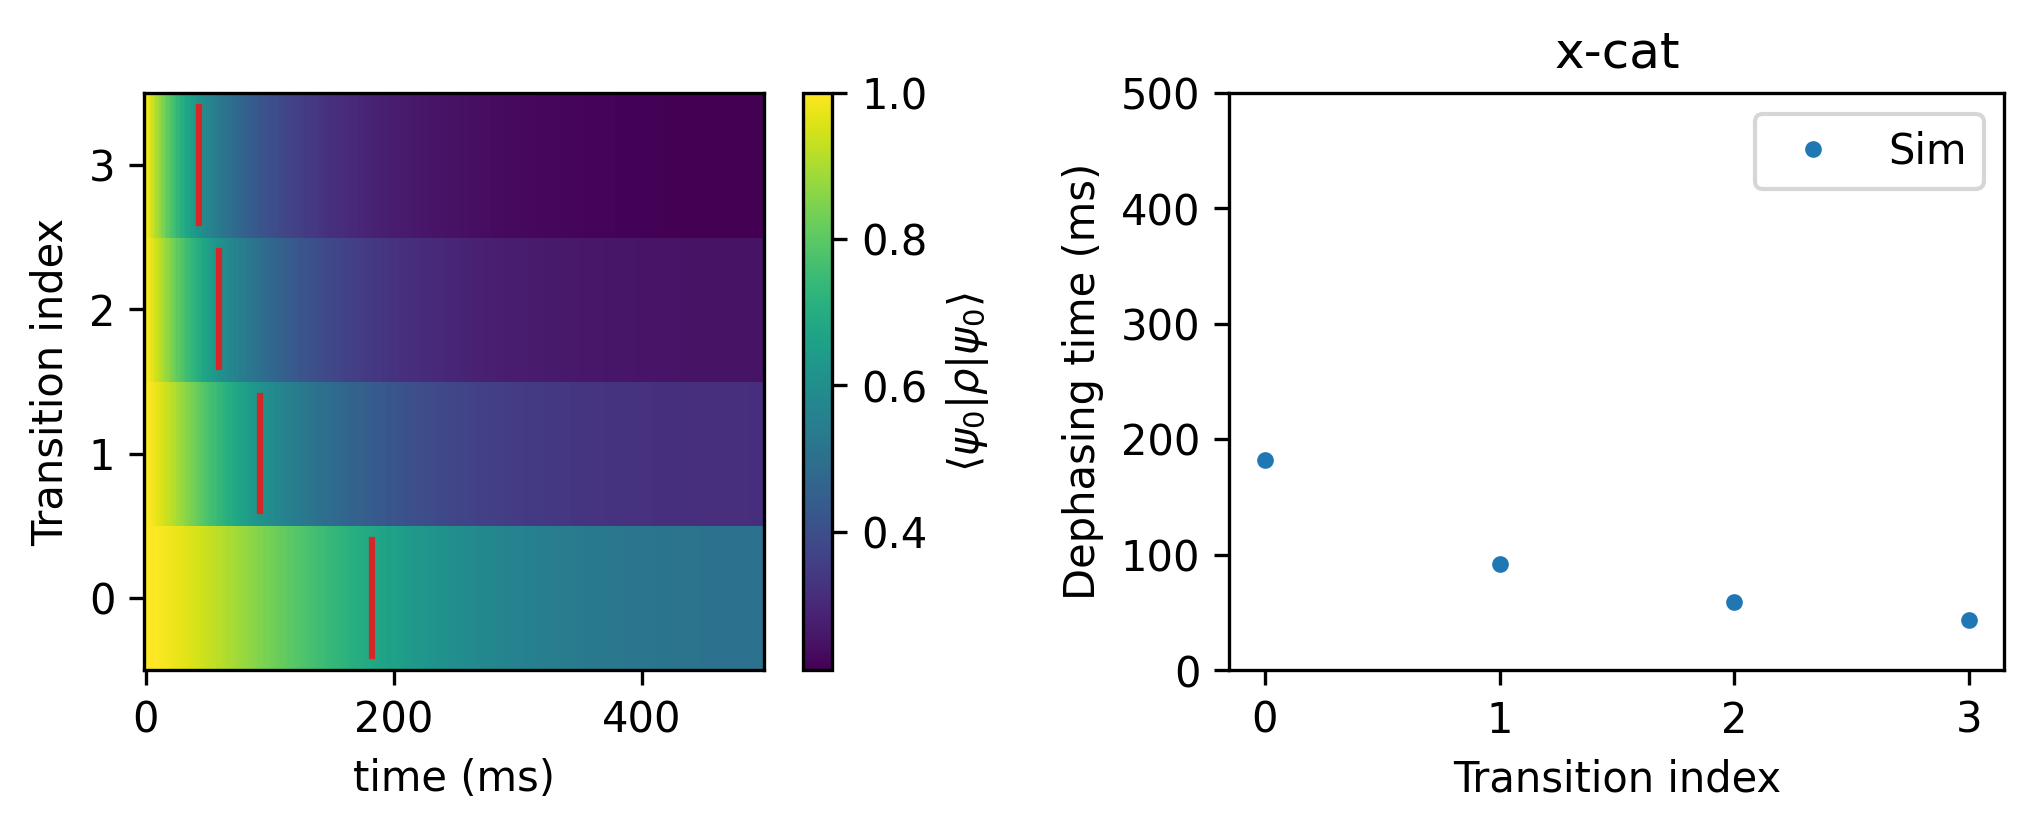

In [863]:
T2s_xdata = np.flip(np.array([46.19, 107.7, 150.8, 233]))*1e-3

plot_free_decay(fidelity, T2s)
plt.title('x-cat')

# Fit

In [482]:
def exponential_decay(t, T2star, amplitude, offset, alpha):
    return amplitude * np.exp(-(t / T2star)**alpha) + offset

exp_model = Model(exponential_decay)
params = Parameters()
params.add('T2star', value=1.0, min=0.1, max=1000.0)
params.add('amplitude', value=1.0, min=0.1)
params.add('offset', value=0.0)
params.add('alpha', value=1.0, min=0.1, max=2.0)

In [483]:
NMR_transition_labels = [
    r"$-7/2 \leftrightarrow -5/2$",
    r"$-5/2 \leftrightarrow -3/2$",
    r"$-3/2 \leftrightarrow -1/2$",
    r"$-1/2 \leftrightarrow +1/2$",
    r"$+1/2 \leftrightarrow +3/2$",
    r"$+3/2 \leftrightarrow +5/2$",
    r"$+5/2 \leftrightarrow +7/2$"
]

## Fit m=1 ramsey and z cats

### process m=1 ramsey data

In [599]:
qc.set_data_root_folder(r"C:\Users\Arjen Vaartjes\UNSW\Scarlett - General\data") # file location
data_T2 = qc.load_data(r'2024-01-01\#005_ionized-nmr-ramsey_20-26-23')

#if qc.load_data() doesn't work, try qc.legacy_import(). load_data is a depricated function in newer versions of QCodes

Data root folder set to C:\Users\Arjen Vaartjes\UNSW\Scarlett - General\data


In [600]:
NMR_transitions = {
    0: r"$-7/2 \leftrightarrow -5/2$",
    1: r"$-5/2 \leftrightarrow -3/2$",
    2: r"$-3/2 \leftrightarrow -1/2$",
    3: r"$-1/2 \leftrightarrow +1/2$",
    4: r"$+1/2 \leftrightarrow +3/2$",
    5: r"$+3/2 \leftrightarrow +5/2$",
    6: r"$+5/2 \leftrightarrow +7/2$"
}

T2_dict = {}

tau = data_T2["Wait_Time_0_0_0"][0][0]

In [601]:
def generate_T2_data(exponents, plot=False):
    """
    Generate T2 decay data and fit T2 times based on given exponents.

    This function fits an exponential sine model to filtered flip probability data for different wait times,
    using fixed exponents. It returns the fitted T2 decay times and their corresponding errors.
    Optionally, it can plot the fit results.

    Parameters:
    exponents (list or numpy array): The exponents for the decay model, one for each state probability set.
    plot (bool, optional): If True, plots the fit results for each state probability set. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2s (numpy array): The fitted T2 decay times.
        - T2s_err (numpy array): The standard errors of the fitted T2 decay times.
    """
    T2s = np.zeros(7)
    T2s_err = np.zeros(7)
    
    for s in range(len(data_T2["target_state_0"])):
        
        osc_model = Model(ExponentialSineFit)
        params = Parameters()
        params.add('tau', value=0.1, min=0.01, max=0.4)
        params.add('amplitude', value=0.5, min=0.4, max=0.6)
        params.add('frequency', value=40, min=30, max=80)
        params.add('phase_offset', value=np.pi/2, min=-np.pi, max=np.pi)
        params.add('offset', value=0.5, min=0.4, max=0.6)
        params.add('alpha', value=exponents[s], min=0.5, max=2.5, vary=False)  #fix exponents
        
        data_subspace = data_T2["filtered_flip_probability_0_1_0_0_0_1"][s].mean(0)
        tau = data_T2["Wait_Time_0_0_0"][0][s]
        result = osc_model.fit(data_subspace, t=tau, params=params)
        T2s[s] = result.params['tau']
        T2s_err[s] = result.params['tau'].stderr
        
        if plot:
            plt.figure(figsize=(3,2))
            plt.plot(tau, result.best_fit)
            plt.plot(tau, data_subspace, '.')
            plt.xlabel('wait time (ms)')
            plt.ylabel('parity contrast')
            plt.title(NMR_transitions[s])

    return T2s, T2s_err

(array([0.02660193, 0.03719805, 0.08050732, 0.25996445, 0.08549667,
        0.04928368, 0.03200008]),
 array([0.00214297, 0.00224487, 0.00551417, 0.0469116 , 0.00622514,
        0.00262147, 0.00247161]))

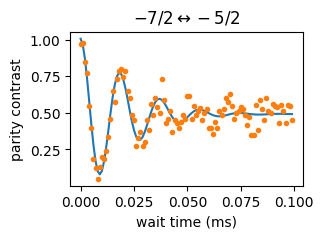

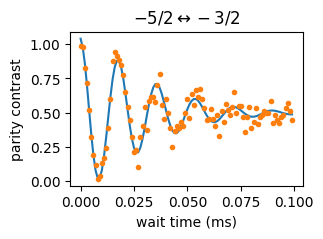

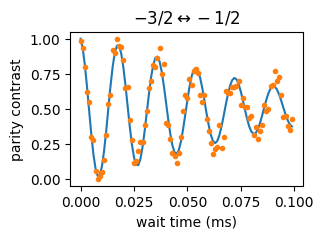

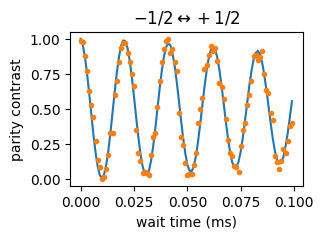

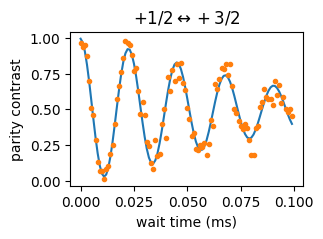

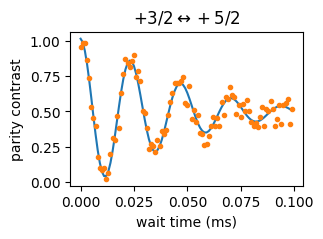

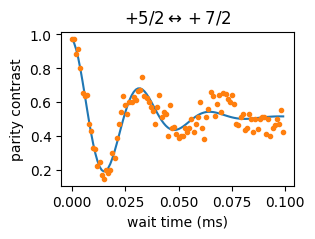

In [602]:
generate_T2_data(np.repeat(1.4, 7), plot=True)

### process z-cat data

In [603]:
data_z_cat_lifetime_7 = qc.load_data(r'2023-12-29\#012_ionized-cat-coherence-generalized-ramsey_17-49-09') # 7/2 -7/2 inside
data_z_cat_lifetime_5 = qc.load_data(r'2023-12-31\#009_ionized-cat-coherence-generalized-ramsey_13-46-19') # 5/2 -5/2 inside
data_z_cat_lifetime_3 = qc.load_data(r'2023-12-31\#008_ionized-cat-coherence-generalized-ramsey_11-25-47') # 3/2 -3/2 inside
data_z_cat_lifetime_1 = qc.load_data(r'2023-12-31\#015_ionized-cat-coherence-generalized-ramsey_18-59-39') # 1/2 -1/2 inside

data_z_cat = [data_z_cat_lifetime_7, data_z_cat_lifetime_5, data_z_cat_lifetime_3, data_z_cat_lifetime_1]

# Evaluate State probabilities

cat_list_dict = {
    "0" : "-7/2 to +7/2", 
    "1" : "-5/2 to +5/2", 
    "2" : "-3/2 to +3/2", 
    "3" : "-1/2 to +1/2", }
filter_outside_subspace = True
lifetimes = []
for data_index in range(len(data_z_cat)):    
    data = data_z_cat[data_index]
    num_esr_lines = len(data["ESR_up_proportions_0_0_0_0_0_0"][0][0][0])
    state_probabilities = np.zeros((len(data['Wait_Time_0_0_0'][0][0]),
                                    len(data["ESR_up_proportions_0_0_0_0_0_0"][0][0][0])))
    state_probabilities_std = np.zeros(np.shape(state_probabilities))
    
    exp_values_Iz =  np.zeros((len(data['Wait_Time_0_0_0'][0][0])))
    exp_values_Iz_std = np.zeros(np.shape(exp_values_Iz))
    
    num_reps = len(data['ESR_up_proportions_0_0_0_0_0_0'][0] )
    
    num_samples = len(data["ESR_up_proportions_0_0_0_0_0_0"][0][0][0][0])
    Iz = qt.jmat(7/2, "z")
    Iz_diagonal = np.real(np.diag(Iz))
    
    for i in range(len(data['Wait_Time_0_0_0'][0][0])):
        state_list_k = np.concatenate( [np.argmax(data['ESR_up_proportions_0_0_0_0_0_0'][0][j][i], axis = 0)\
                              for j in range(len(data['ESR_up_proportions_0_0_0_0_0_0'][0]))])
        state_list_k_filtered = [n for n in state_list_k if (n<=(num_esr_lines-data_index-1) and  n>=(data_index))]
        if filter_outside_subspace == True:
#             if (len(state_list_k) != len(state_list_k_filtered)): print("Data Filtered")
            state_list_k = state_list_k_filtered
        for k in range(num_esr_lines):
            state_probabilities[i][k] = np.sum([state_list_k] == np.array([k]*len(state_list_k)))/len(state_list_k)
            state_probabilities_std[i][k] =\
                np.std([state_list_k] == np.array([k]*len(state_list_k)))/np.sqrt(len(state_list_k))
        exp_values_Iz[i] = np.sum(Iz_diagonal[[meas for meas in state_list_k]])/len(state_list_k)
        exp_values_Iz_std[i] = np.std(Iz_diagonal[[meas for meas in state_list_k]])/np.sqrt(len(state_list_k))


    lifetimes.append({
        "State Probabilities" : state_probabilities,
        "State Probabilities Error" : state_probabilities_std,
        "Wait time" : data['Wait_Time_0_0_0'][0][0],
        "I_z" : exp_values_Iz,
        "I_z Error": exp_values_Iz_std,
        "Artificial Detuning": data["Artificial_Detuning_1"][0]
    }
    )

In [604]:
def generate_T2_z(exponents, plot=False):
    """
    Generate T2 decay times for the z-component based on given exponents.

    This function fits an exponential sine model to the state probability data for different wait times,
    using fixed exponents. It returns the fitted T2 decay times and their corresponding errors. 
    Optionally, it can plot the fit results.

    Parameters:
    exponents (list or numpy array): The exponents for the decay model, one for each state probability set.
    plot (bool, optional): If True, plots the fit results for each state probability set. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2s (numpy array): The fitted T2 decay times.
        - T2s_err (numpy array): The standard errors of the fitted T2 decay times.
    """
    T2s = np.zeros(len(lifetimes))
    T2s_err = np.zeros(len(lifetimes))
    for s in range(len(lifetimes)):
        tau = lifetimes[s]["Wait time"]
        y = lifetimes[s]["State Probabilities"][:, s]

        osc_model = Model(ExponentialSineFit)
        params = Parameters()
        params.add('tau', value=0.1, min=0.01, max=0.4)
        params.add('amplitude', value=0.5, min=0.4, max=0.6)
        params.add('frequency', value=80/(s+1), min=10, max=120)
        params.add('phase_offset', value=0, min=-np.pi, max=np.pi)
        params.add('offset', value=0.5, min=0.4, max=0.6)
        params.add('alpha', value=exponents[s], min=0.5, max=2.5, vary=False)  #fix exponents

        result = osc_model.fit(y, t=tau, params=params)
        T2s[s] = result.params['tau']
        T2s_err[s] = result.params['tau'].stderr
        
        if plot:
            plt.figure(figsize=(3,2))
            plt.plot(tau*1e3, result.best_fit)
            plt.plot(tau*1e3, y, '.')
            plt.title(r'Spin %d/2'% ((4-s)*2-1))
            plt.xlabel('Wait time (ms)')
            plt.ylabel('flip probability')
        
    return T2s, T2s_err

(array([0.01560382, 0.0309247 , 0.07585109, 0.20650354]),
 array([0.00146257, 0.00237677, 0.00637418, 0.02650127]))

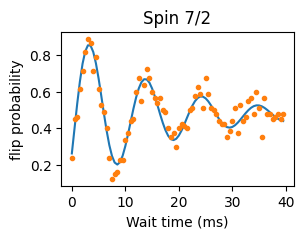

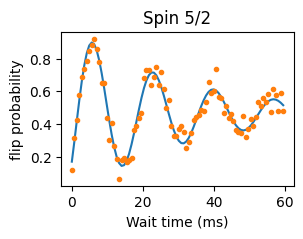

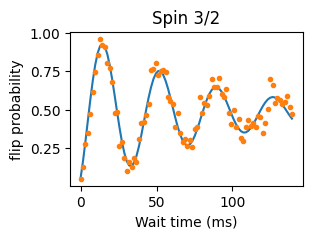

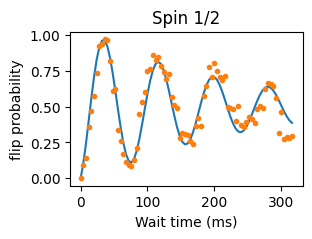

In [605]:
generate_T2_z([1,1,1,1], plot=True)

### process x-cat data

In [606]:
data_x_cat_lifetime_7 = qc.load_data(r'2023-12-13\#003_Global_Rotation_ionized_generalized_ramsey_13-55-16') # 7/2 -7/2 inside
data_x_cat_lifetime_5 = qc.load_data(r'2024-01-25\#006_ionized-cat-coherence_16-52-05') # 5/2 -5/2 inside
data_x_cat_lifetime_3 = qc.load_data(r'2024-01-29\#005_ionized-cat-coherence_15-21-26') # 3/2 -3/2 inside
data_x_cat_lifetime_1 = qc.load_data(r'2023-12-31\#015_ionized-cat-coherence-generalized-ramsey_18-59-39') # 1/2 -1/2 inside

data_x_cat = [data_x_cat_lifetime_7, data_x_cat_lifetime_5, data_x_cat_lifetime_3, data_x_cat_lifetime_1]

In [607]:
lifetimes_x_cat = []
for data_index in range(len(data_x_cat)):
    data = data_x_cat[data_index]
    num_esr_lines = 8

    try:
        wait_time = data["Wait_Time_0_0_0"][0]
        up_proportions = data["ESR_up_proportions_0_0_0_0_0_0"][0]
    except:
        wait_time = data["Wait_Time_0_0"]
        up_proportions = data["ESR_up_proportions_0_0_0_0_0"]     

    state_probabilities = np.zeros((len(wait_time[0]), len(up_proportions[0][0]) ))
    state_probabilities_std = np.zeros(np.shape(state_probabilities))

    exp_values_Iz = np.zeros(len(wait_time[0]))
    exp_values_Iz_std = np.zeros(np.shape(exp_values_Iz))

    for i in range(len(wait_time[0])):
        state_list_k = np.concatenate( [np.argmax(up_proportions[j][i], axis = 0)\
                              for j in range(len(up_proportions))])
        state_list_k_filtered = [n for n in state_list_k if (n<=(num_esr_lines-data_index-1) and  n>=(data_index))]
        if filter_outside_subspace == True:
            # if (len(state_list_k) != len(state_list_k_filtered)): print("Data Filtered")
            state_list_k = state_list_k_filtered
        for k in range(num_esr_lines):
            state_probabilities[i][k] = np.sum([state_list_k] == np.array([k]*len(state_list_k)))/len(state_list_k)
            state_probabilities_std[i][k] = np.std([state_list_k] == np.array([k]*len(state_list_k)))/np.sqrt(len(state_list_k))
        exp_values_Iz[i] = np.sum(Iz_diagonal[[meas for meas in state_list_k]])/len(state_list_k)
        exp_values_Iz_std[i] = np.std(Iz_diagonal[[meas for meas in state_list_k]])/np.sqrt(len(state_list_k))

    lifetimes_x_cat.append({
        "State Probabilities" : state_probabilities,
        "State Probabilities Error" : state_probabilities_std,
        "I_z" : exp_values_Iz,
        "I_z Error": exp_values_Iz_std,
        "Wait time" : wait_time[0],
            })

In [753]:
lifetimes_x_cat[0]['I_z']

array([-3.49, -3.11, -2.31, -0.85,  0.38,  1.69,  2.53,  3.14,  3.02,
        2.53,  1.8 ,  0.41, -0.27, -1.19, -1.81, -2.4 , -2.41, -2.18,
       -0.99, -0.83,  0.09,  0.98,  1.68,  2.22,  2.03,  1.94,  0.79,
       -0.15, -0.4 , -0.78, -1.02, -0.94, -1.3 , -0.55, -0.15,  0.36,
        0.71,  0.69,  1.  ,  0.27,  0.36,  0.71,  0.44, -0.08, -0.83,
       -0.71, -0.17,  0.02,  0.93,  0.69,  1.12,  1.21,  0.72,  0.58,
        0.32, -0.74, -0.82, -0.88, -0.65, -1.27, -0.81, -0.04,  0.56,
        0.43,  0.88,  0.6 ,  0.52,  0.35,  0.37,  0.07, -0.54, -0.63,
       -0.81, -0.84, -0.77, -0.75, -0.56,  0.23,  0.68,  0.72,  0.87,
        0.58,  0.32,  0.25,  0.09, -0.14, -0.63, -0.9 , -0.53, -0.98,
       -0.4 ,  0.04,  0.88,  0.66,  0.6 ,  0.11,  0.48,  0.41,  0.21,
       -0.19,  0.09, -0.1 ,  0.07, -0.61, -0.57, -0.58, -0.12,  0.69,
        0.73,  0.94,  0.9 ,  0.88,  0.02,  0.29, -0.37, -0.53, -1.03,
       -0.81, -0.18, -0.56,  0.27,  0.6 ,  0.62,  1.17,  0.98])

In [808]:
def generate_T2_x(exponents, plot=False):
    """
    Generate T2 decay times for the x-cats based on given exponents.

    This function fits an exponential sine model to the state probability data for different wait times,
    using fixed exponents. It returns the fitted T2 decay times and their corresponding errors. 
    Optionally, it can plot the fit results.

    Parameters:
    exponents (list or numpy array): The exponents for the decay model, one for each state probability set.
    plot (bool, optional): If True, plots the fit results for each state probability set. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2s (numpy array): The fitted T2 decay times.
        - T2s_err (numpy array): The standard errors of the fitted T2 decay times.
    """
    T2s = np.zeros(len(lifetimes_x_cat))
    T2s_err = np.zeros(len(lifetimes_x_cat))
    for s in range(len(lifetimes_x_cat)):
        tau = lifetimes_x_cat[s]["Wait time"]
        y = lifetimes_x_cat[s]["I_z"]

        osc_model = Model(ExponentialSineFit)
        params = Parameters()
        params.add('tau', value=0.16, min=0.01, max=0.4)
        params.add('amplitude', value=np.max(y), min=0.5, max=3.5)
        params.add('frequency', value=51/(s+1), min=10, max=120)
        params.add('phase_offset', value=-np.pi/2, min=-np.pi, max=np.pi)
        params.add('offset', value=0, min=-0.6, max=0.6)
        params.add('alpha', value=exponents[s], min=0.5, max=1.5, vary=False)  #fix exponents

        result = osc_model.fit(y, t=tau, params=params)
        T2s[s] = result.params['tau']
        T2s_err[s] = result.params['tau'].stderr
        
        if plot:
            plt.figure(figsize=(3,2))
            plt.plot(tau*1e3, result.best_fit)
            plt.plot(tau*1e3, y, '.')
            plt.title(r'Spin %d/2'% ((4-s)*2-1))
            plt.xlabel('Wait time (ms)')
            plt.ylabel('flip probability')
        
    return T2s, T2s_err

(array([0.05715901, 0.10793188, 0.14889774, 0.21166497]),
 array([0.00545445, 0.01455188, 0.02700416, 0.02506923]))

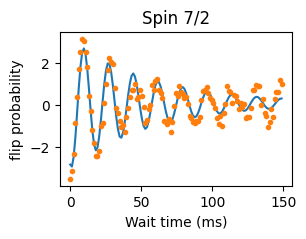

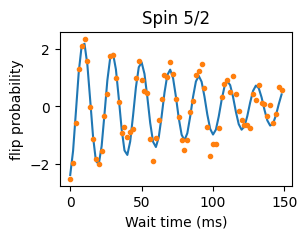

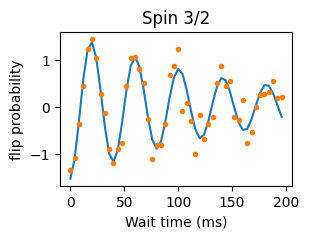

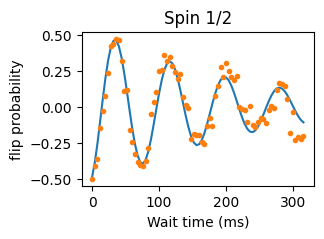

In [809]:
generate_T2_x([1,1,1,1.1], plot=True)

The idea of the fitting is to optimize T2* values for both the m=1 ramseys and z-cat ramseys:

\begin{itemize}
    \item Pick values for T2*_m, T2*_e, exponent_m, exponent_e
    \item generate a set of T2* values from the Ramsey measurement data (both m=1 Ramsey and z-cats) using fixed values for exponent_m, exponent_e
    \item simulate a set of T2* values with values for T2*_m, T2*_e, exponent_m, exponent_e (both m=1 and z-cats)
    \item concatenate T2* arrays for m=1 and z-cats, both for data and simulation
    \item minimize residual = (data - simulation) with free parameters T2*_m, T2*_e, exponent_m, exponent_e
\end{itemize}

### fitting helpers

In [ ]:
def calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """Simulate m=1 Ramsey free decay and fit T2* times and stretch exponents.

    Parameters
    ----------
    t2star_m, t2star_e : float
        Magnetic and electric T2* times.
    exponent_m, exponent_e : float
        Stretch exponents for magnetic and electric noise.
    plot : bool
        If True, call plot_free_decay on the result.

    Returns
    -------
    T2s : ndarray, shape (7,)
        Fitted T2* times for each m=1 transition superposition.
    alphas : ndarray, shape (7,)
        Fitted stretch exponents.
    """
    dt = 2e-3
    tmax = 500e-3
    times = np.arange(0, tmax, dt)
    psi0s = [(qt.basis(8, i) + qt.basis(8, i + 1)).unit() for i in range(7)]

    c_ops = get_cops_sb_qudit(t2star_m, t2star_e, exponent_m, exponent_e)
    fidelity, T2s, alphas = run_free_decay(psi0s, times, c_ops)

    if plot:
        plot_free_decay(fidelity, T2s)

    return T2s, alphas


def calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """Simulate z-cat free decay and fit T2* times and stretch exponents.

    Parameters
    ----------
    t2star_m, t2star_e : float
        Magnetic and electric T2* times.
    exponent_m, exponent_e : float
        Stretch exponents for magnetic and electric noise.
    plot : bool
        If True, call plot_free_decay on the result.

    Returns
    -------
    T2s : ndarray, shape (4,)
    alphas : ndarray, shape (4,)
    """
    psi0s = [
        (qt.basis(8, 3) + qt.basis(8, 4)).unit(),
        (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
        (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
        (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
    ]
    dt = 2e-3
    tmax = 500e-3
    times = np.arange(0, tmax, dt)
    c_ops = get_cops_sb_qudit(t2star_m, t2star_e, exponent_m, exponent_e)
    fidelity, T2s, alphas = run_free_decay(psi0s, times, c_ops)

    if plot:
        plot_free_decay(fidelity, T2s)

    return T2s, alphas


def calculate_x_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """Simulate x-cat free decay and fit T2* times and stretch exponents.

    Parameters
    ----------
    t2star_m, t2star_e : float
        Magnetic and electric T2* times.
    exponent_m, exponent_e : float
        Stretch exponents for magnetic and electric noise.
    plot : bool
        If True, call plot_free_decay on the result.

    Returns
    -------
    T2s : ndarray, shape (4,)
    alphas : ndarray, shape (4,)
    """
    nx = np.array([1, 0, 0])
    psi0s = [
        qt.Qobj(subspace_rotation_operator(1/2, np.pi/2, nx)) * (qt.basis(8, 3) + qt.basis(8, 4)).unit(),
        qt.Qobj(subspace_rotation_operator(3/2, np.pi/2, nx)) * (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
        qt.Qobj(subspace_rotation_operator(5/2, np.pi/2, nx)) * (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
        qt.Qobj(subspace_rotation_operator(7/2, np.pi/2, nx)) * (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
    ]
    dt = 2e-3
    tmax = 500e-3
    times = np.arange(0, tmax, dt)
    c_ops = get_cops_sb_qudit(t2star_m, t2star_e, exponent_m, exponent_e)
    fidelity, T2s, alphas = run_free_decay(psi0s, times, c_ops)

    if plot:
        plot_free_decay(fidelity, T2s)

    return T2s, alphas


def generate_T2_data(exponents, plot=False):
    """Fit experimental m=1 Ramsey data to extract T2* times at fixed stretch exponents.

    Parameters
    ----------
    exponents : array_like, length 7
        Stretch exponents to hold fixed during the fit, one per NMR transition.
    plot : bool
        If True, plot each individual fit.

    Returns
    -------
    T2s : ndarray, shape (7,)
    T2s_err : ndarray, shape (7,)
    """
    T2s = np.zeros(7)
    T2s_err = np.zeros(7)

    for s in range(len(data_T2["target_state_0"])):
        osc_model = Model(ExponentialSineFit)
        params = Parameters()
        params.add('tau', value=0.1, min=0.01, max=0.4)
        params.add('amplitude', value=0.5, min=0.4, max=0.6)
        params.add('frequency', value=40, min=30, max=80)
        params.add('phase_offset', value=np.pi / 2, min=-np.pi, max=np.pi)
        params.add('offset', value=0.5, min=0.4, max=0.6)
        params.add('alpha', value=exponents[s], min=0.5, max=2.5, vary=False)

        data_subspace = data_T2["filtered_flip_probability_0_1_0_0_0_1"][s].mean(0)
        tau = data_T2["Wait_Time_0_0_0"][0][s]
        result = osc_model.fit(data_subspace, t=tau, params=params)
        T2s[s] = result.params['tau']
        T2s_err[s] = result.params['tau'].stderr

        if plot:
            plt.figure(figsize=(3, 2))
            plt.plot(tau, result.best_fit)
            plt.plot(tau, data_subspace, '.')
            plt.xlabel('wait time (ms)')
            plt.ylabel('parity contrast')
            plt.title(NMR_transitions[s])

    return T2s, T2s_err

In [811]:
alphas

array([1.31498615, 1.32394073, 1.36389614, 1.5008402 , 1.36389613,
       1.3239407 , 1.31498611])

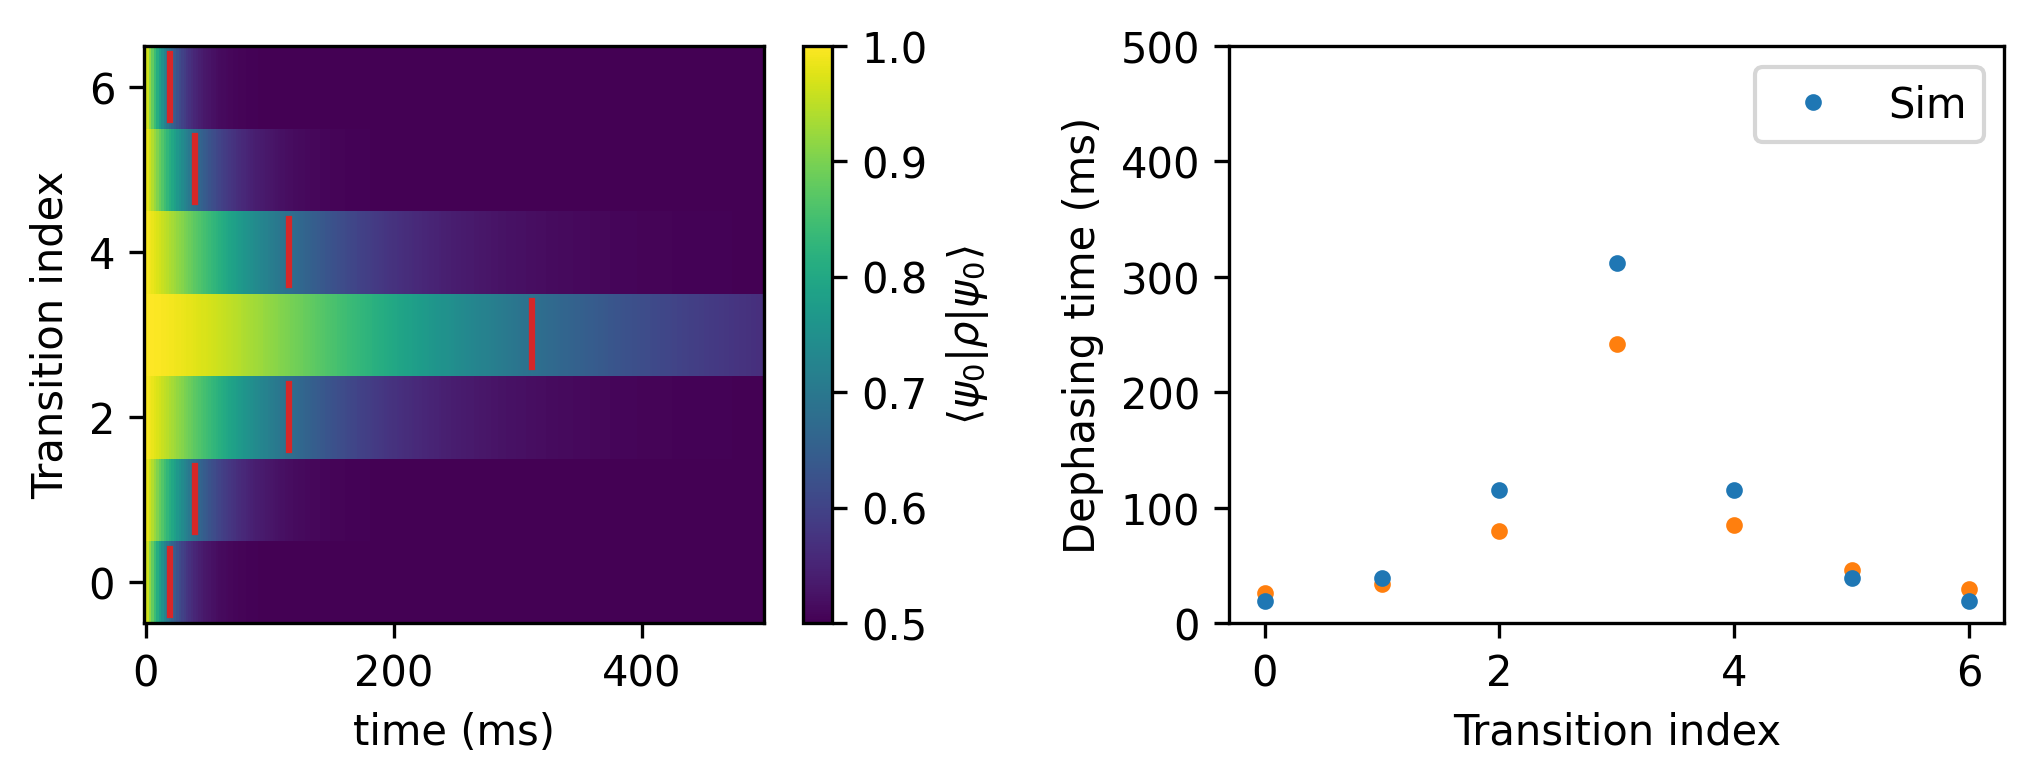

In [812]:
T2_sim, alphas = calculate_so2_T2_exponents(t2star_m=300e-3, t2star_e=500e-3, exponent_m=1.5, exponent_e=1.1, plot=True)
T2_data, T2_err = generate_T2_data(alphas)
plt.plot(T2_data*1e3, '.')

In [858]:
psi0s = [subspace_rotation_arb_vec(1/2, np.pi/2, nx)*(qt.basis(8, 3) + qt.basis(8, 4)).unit(),
         subspace_rotation_arb_vec(3/2, np.pi/2, nx)*(qt.basis(8, 2) + qt.basis(8, 5)).unit(),
         subspace_rotation_arb_vec(5/2, np.pi/2, nx)*(qt.basis(8, 1) + qt.basis(8, 6)).unit(),
         subspace_rotation_arb_vec(7/2, np.pi/2, nx)*(qt.basis(8, 0) + qt.basis(8, 7)).unit(),
]

In [859]:
psi0s[-1]

array([[ 0.0625    -0.0625j    ],
       [-0.16535946+0.16535946j],
       [-0.28641098+0.28641098j],
       [ 0.36975499-0.36975499j],
       [ 0.36975499-0.36975499j],
       [-0.28641098+0.28641098j],
       [-0.16535946+0.16535946j],
       [ 0.0625    -0.0625j    ]])

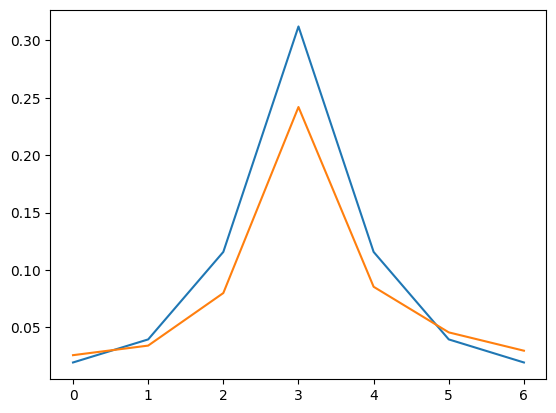

In [813]:
#example for m=1 ramseys
plt.plot(T2_sim)
plt.plot(T2_data)

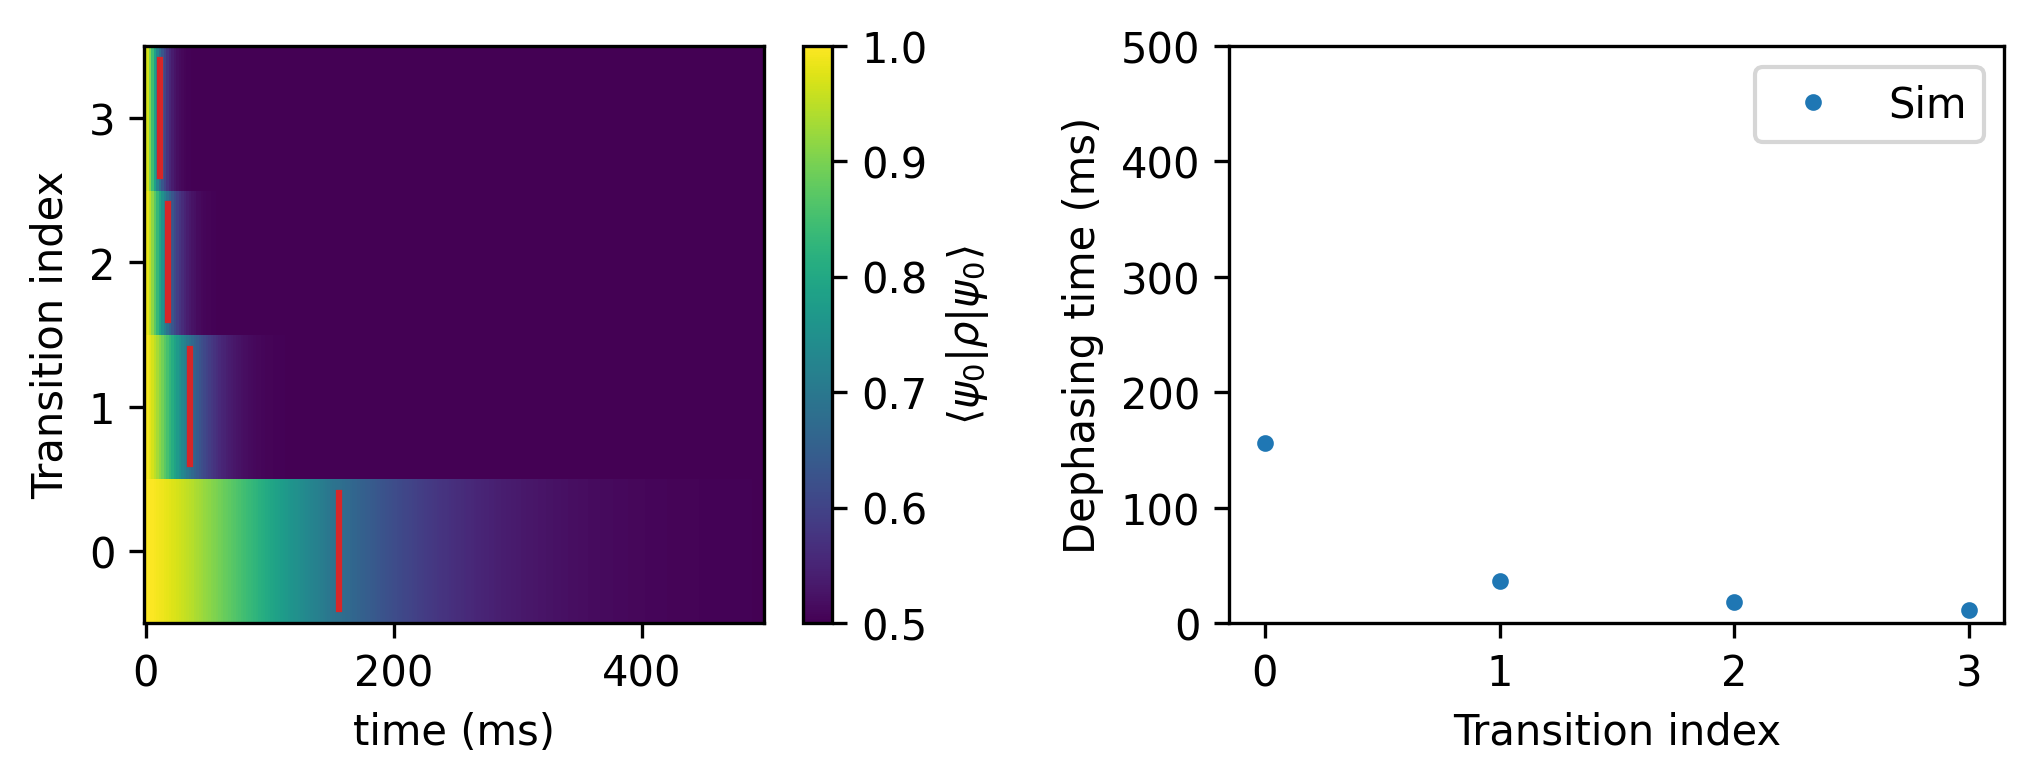

In [814]:
# z-cats example
T2_sim = calculate_z_T2_exponents(t2star_m=150e-3, t2star_e=100e-3, exponent_m=1.5, exponent_e=1.1, plot=True)

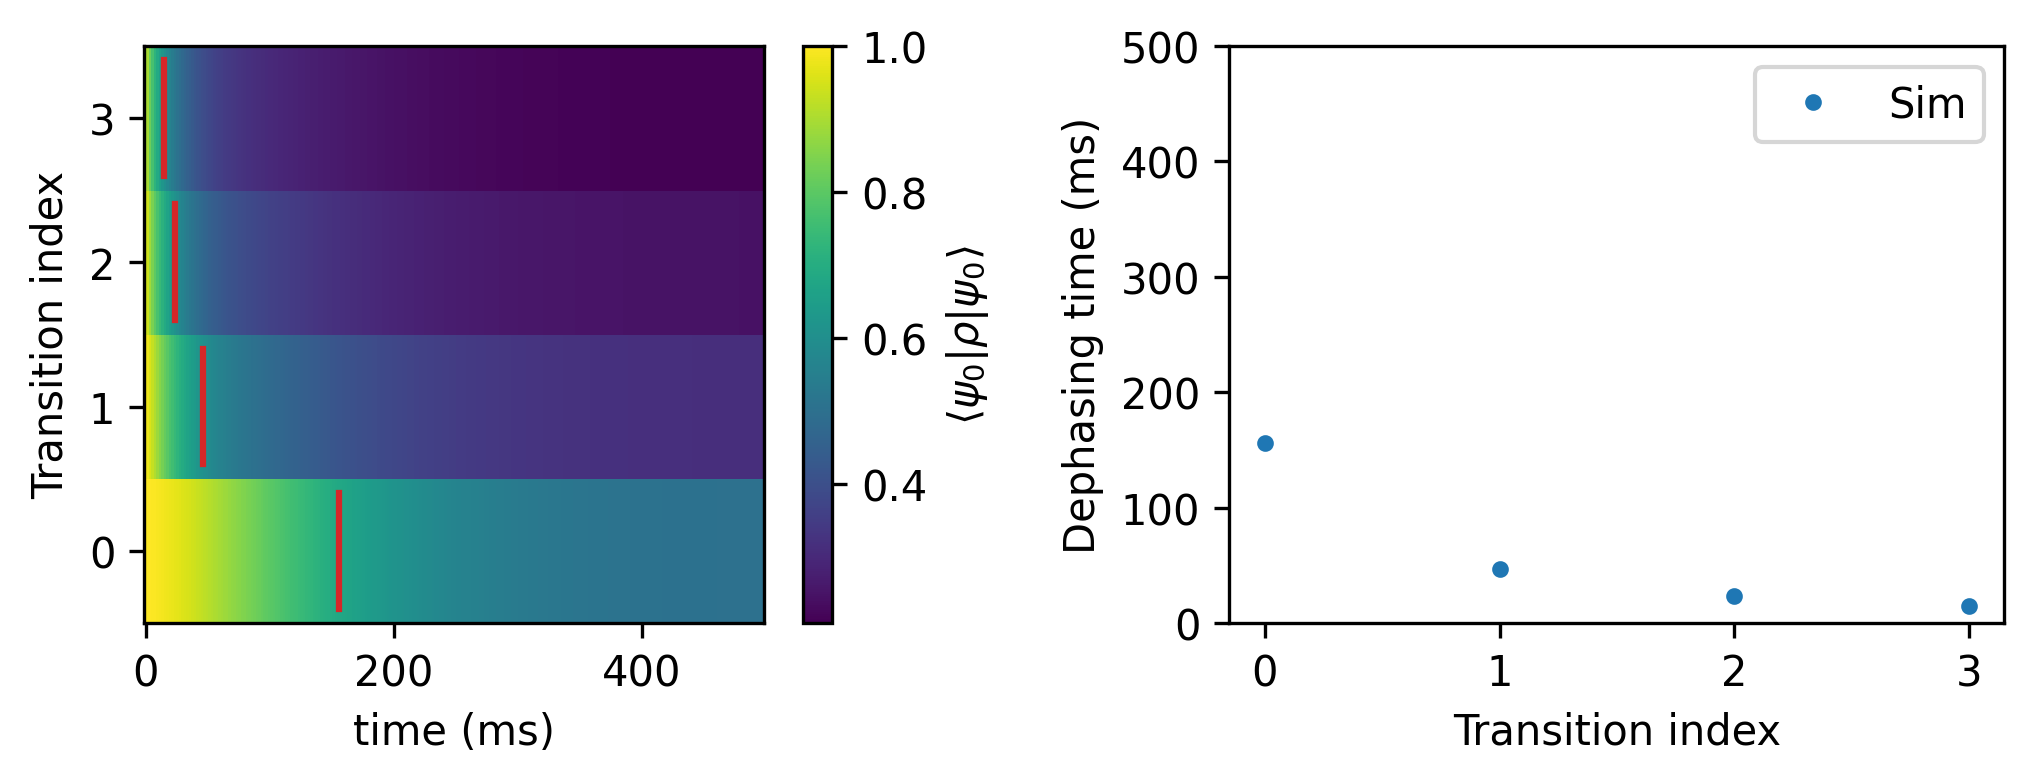

In [815]:
# z-cats example
T2_sim = calculate_x_T2_exponents(t2star_m=150e-3, t2star_e=100e-3, exponent_m=1.5, exponent_e=1.1, plot=True)

### fit

In [854]:
# Define a wrapper function for lmfit
def residual(params):
    t2star_m = params['T2_m'].value
    t2star_e = params['T2_e'].value 
    exponent_m = params['exponent_m'].value 
    exponent_e = params['exponent_e'].value
    
    # m=1
    T2_model, alphas = calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data, T2_err = generate_T2_data(alphas)
    
    # cats
    T2_model_z, alphas_z = calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data_z, T2_err_z = generate_T2_z(alphas_z, plot=False)
    
    T2_model_x, alphas_x = calculate_x_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data_x, T2_err_x = generate_T2_x(alphas_x, plot=False)
    
#     # concatenate m=1 ramsey and z-cat states arrays
    model = np.concatenate([T2_model, T2_model_z[:-1], T2_model_x[1:-1]]) # i remove the last element because they are all the -1/2->1/2 superposition
    data = np.concatenate([T2_data, np.flip(T2_data_z)[:-1], np.flip(T2_data_x)[1:-1]])
    
    return (1/model - 1/data)

# Create lmfit Parameters object
fit_params = Parameters()
fit_params.add('exponent_m', value=1.5, min=1.0, max=1.7)
fit_params.add('exponent_e', value=1.4, min=1.0, max=1.7)

fit_params.add('T2_m', value=200-3, min=120e-3, max=250e-3)
fit_params.add('T2_e', value=163e-3, min=100e-3, max=800e-3)

# optimize (this can take a minute)
result = minimize(residual, fit_params, method='nelder-mead')

In [855]:
result

# Visualisation

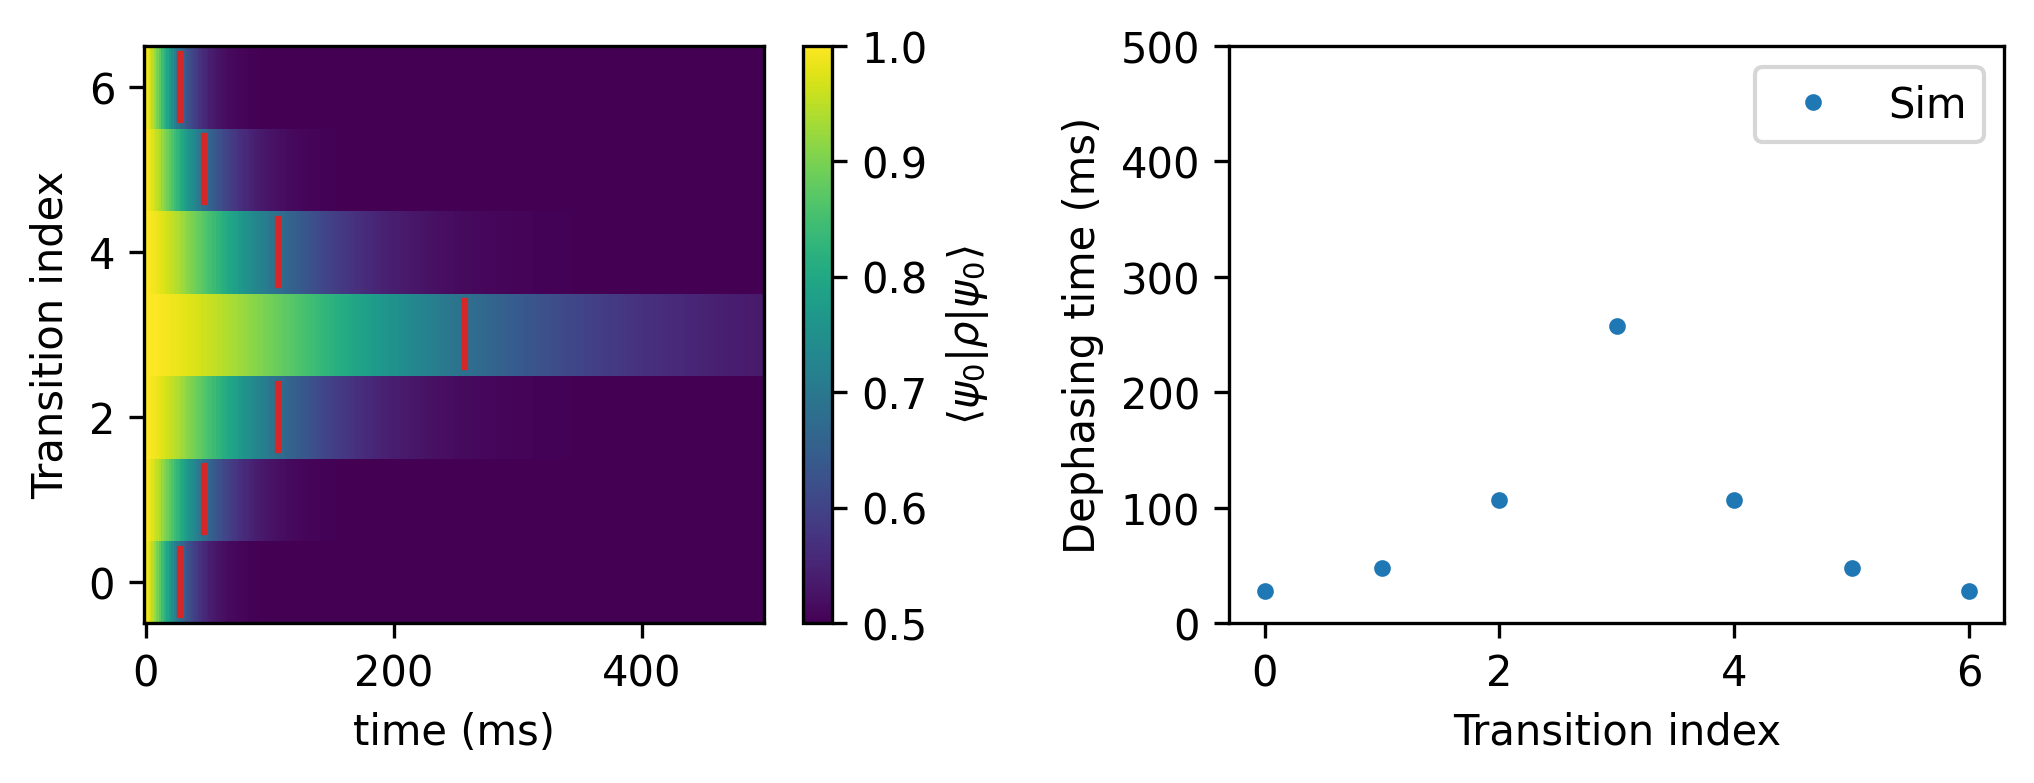

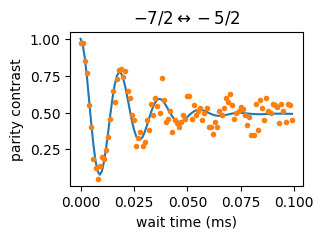

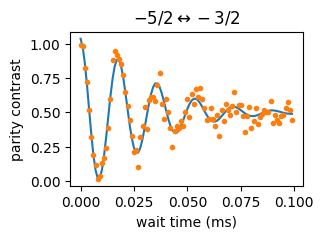

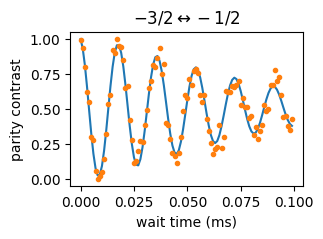

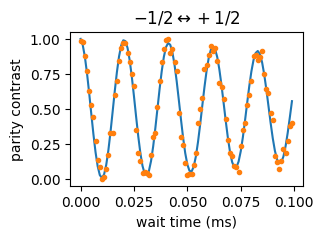

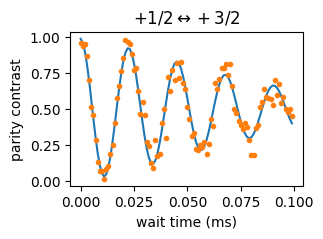

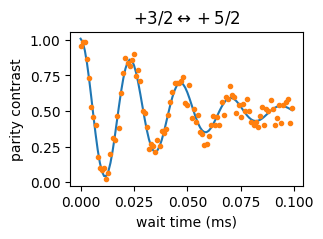

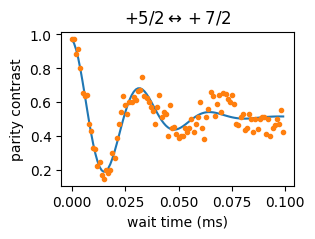

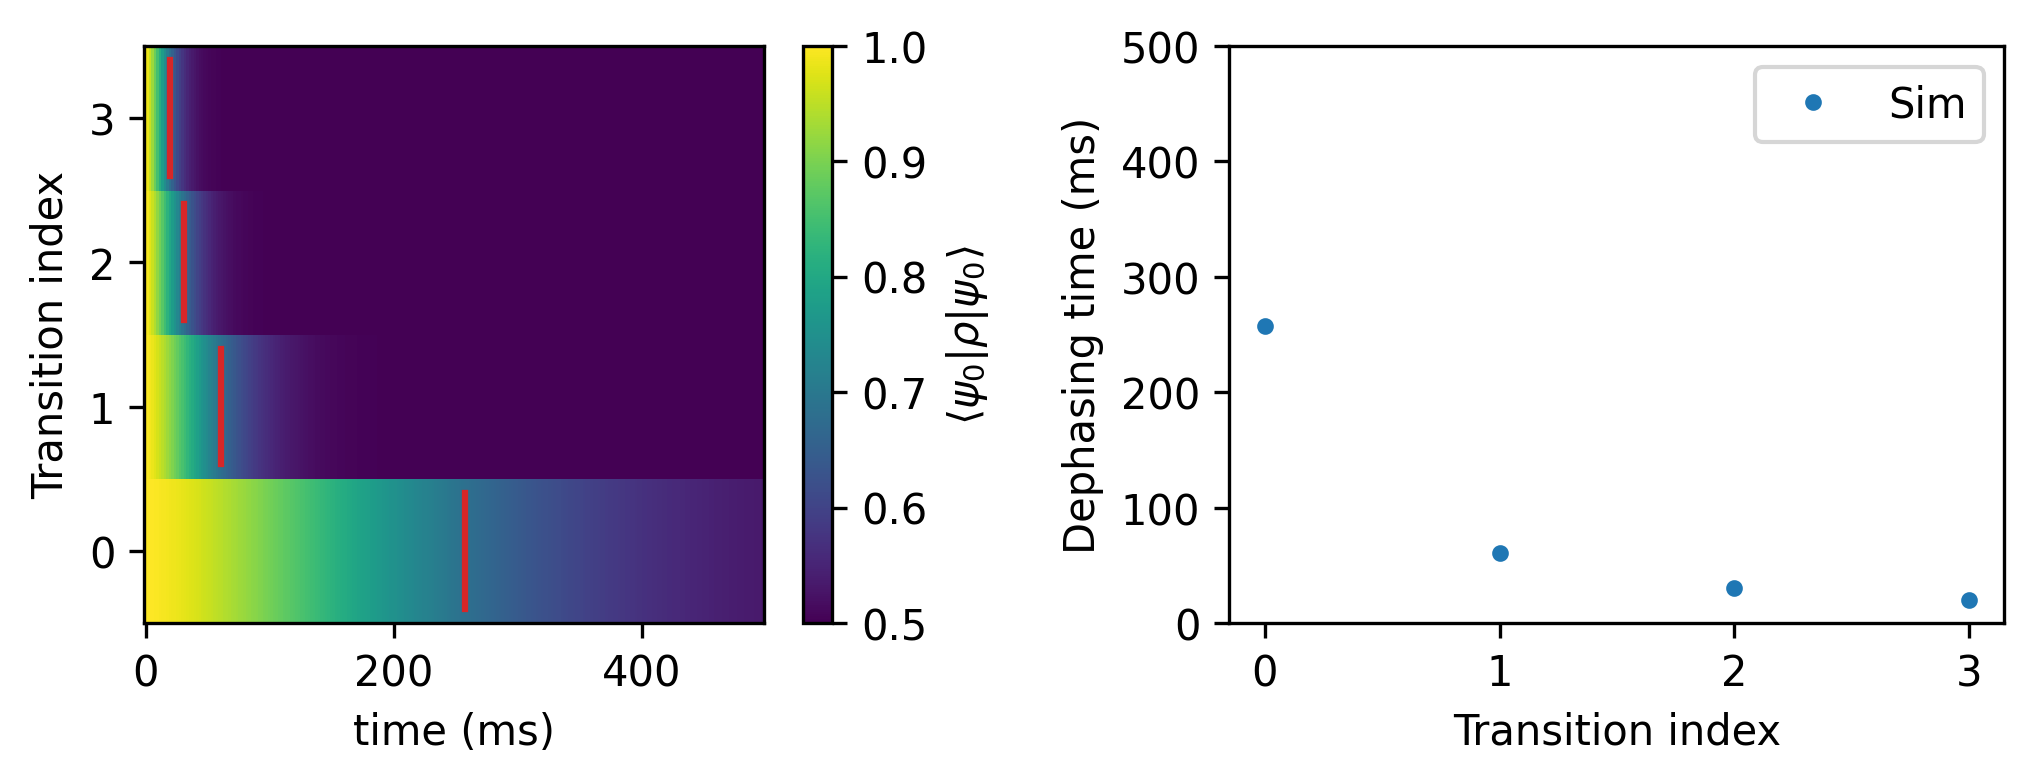

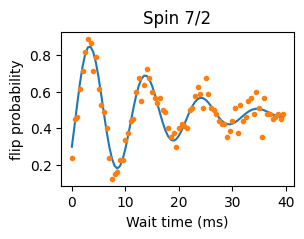

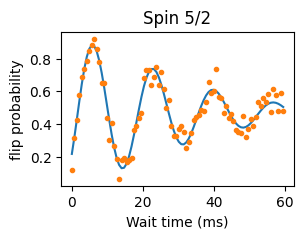

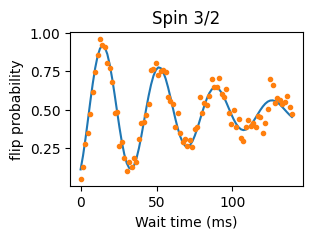

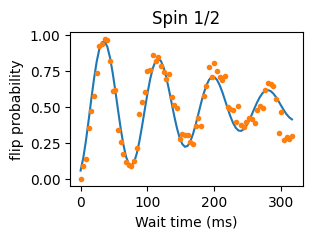

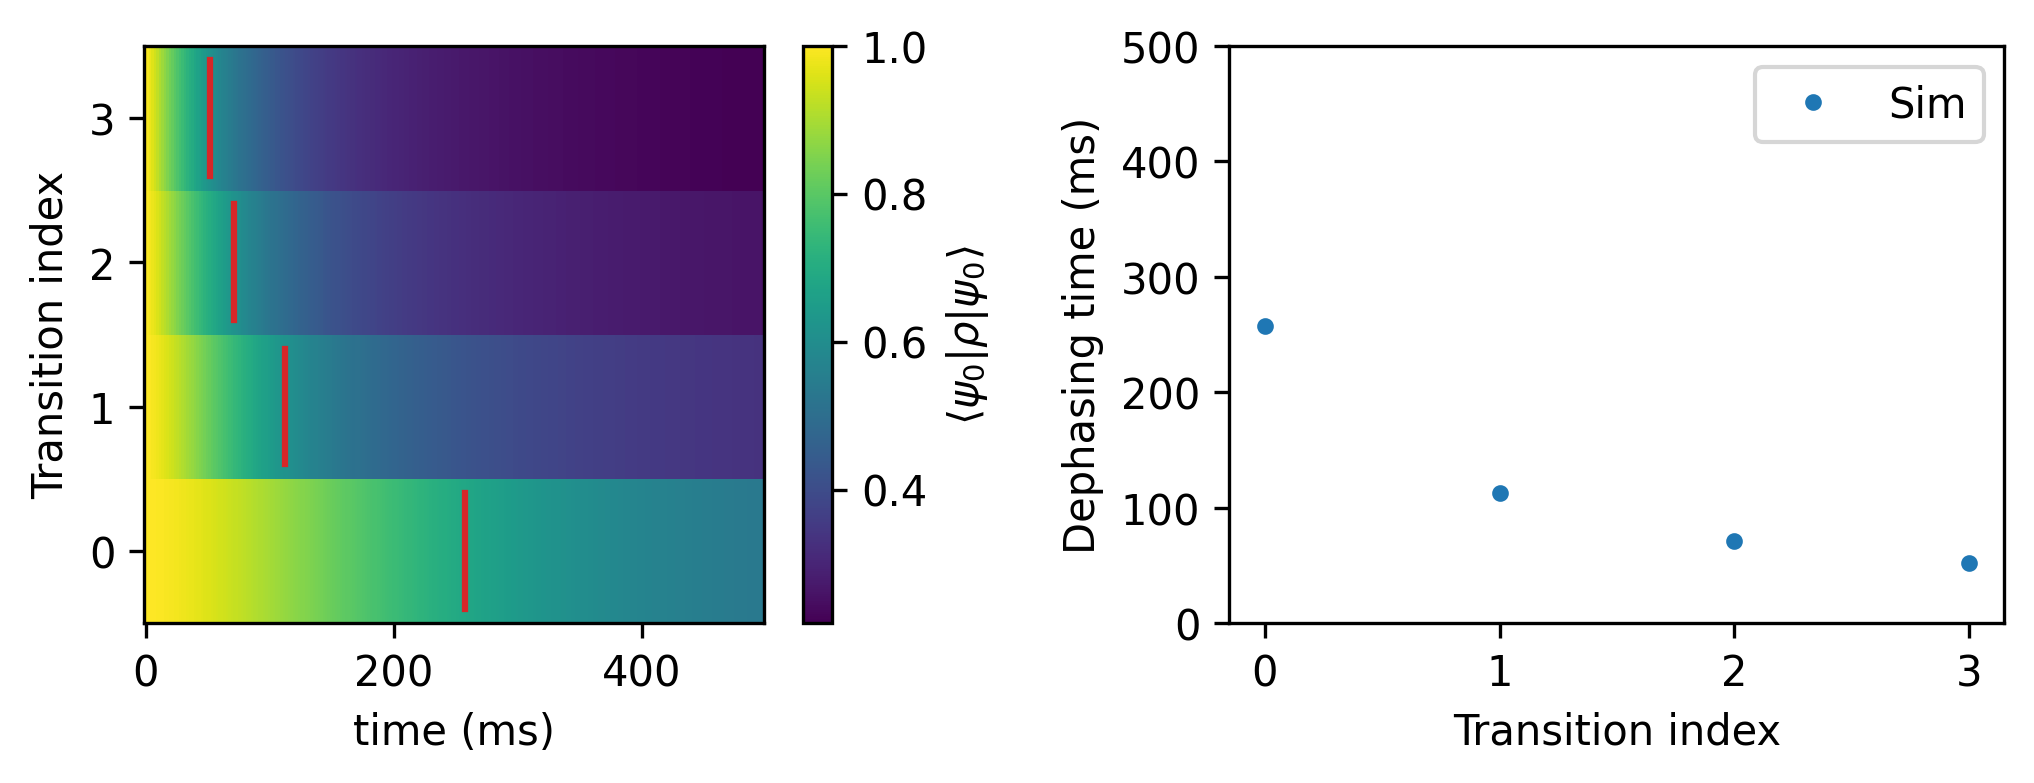

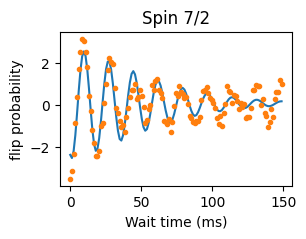

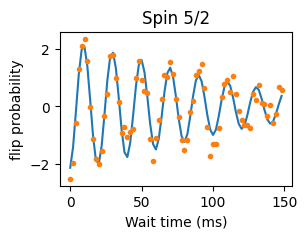

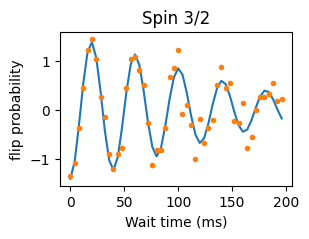

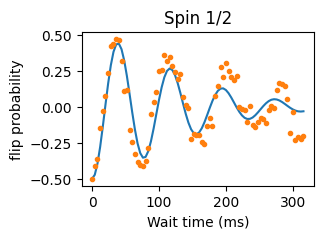

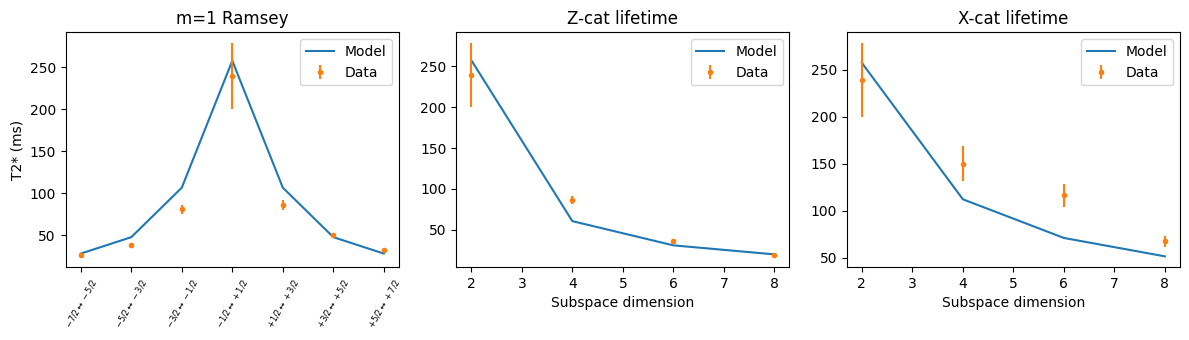

In [856]:
t2star_m = result.params['T2_m']
t2star_e = result.params['T2_e'] 
exponent_m = result.params['exponent_m'] 
exponent_e = result.params['exponent_e']

T2_model, alphas = calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_data, T2_err = generate_T2_data(alphas, plot=True)
T2_model_z, alphas_z = calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_z_data, T2_z_err = generate_T2_z(alphas_z, plot=True)
T2_model_x, alphas_x = calculate_x_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_x_data, T2_x_err = generate_T2_x(alphas_x, plot=True)

T2_z_data[-1] = T2_data[3]
T2_z_err[-1] = T2_err[3]

T2_x_data[-1] = T2_data[3]
T2_x_err[-1] = T2_err[3]
# T2_x_err[0] = 0


fig, ax = plt.subplots(1,3,figsize=(12, 3.5))
ax[0].plot(np.arange(7), T2_model*1e3, label='Model')
ax[0].errorbar(np.arange(7), T2_data*1e3, T2_err*1e3, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 6, rotation=60)
ax[0].set_title('m=1 Ramsey')
ax[0].set_ylabel('T2* (ms)')
ax[0].legend()

ax[1].plot([2, 4, 6, 8], T2_model_z*1e3, label='Model')
ax[1].errorbar([2, 4, 6, 8], np.flip(T2_z_data)*1e3, np.flip(T2_z_err)*1e3, marker='.', label='Data', ls='None')
ax[1].set_xlabel('Subspace dimension')
ax[1].set_title('Z-cat lifetime')
ax[1].legend()

ax[2].plot([2, 4, 6, 8], T2_model_x*1e3, label='Model')
ax[2].errorbar([2, 4, 6, 8], np.flip(T2_x_data)*1e3, np.flip(T2_x_err)*1e3, marker='.', label='Data', ls='None')
ax[2].set_xlabel('Subspace dimension')

ax[2].set_title('X-cat lifetime')
ax[2].legend()
plt.tight_layout()


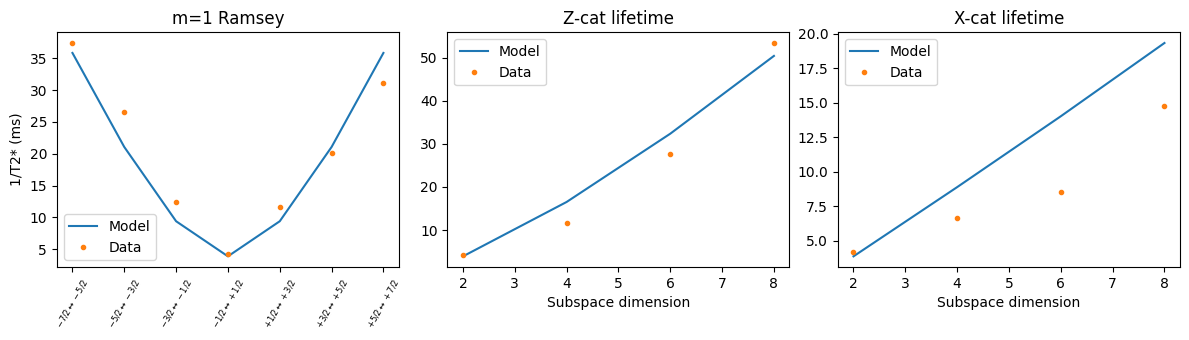

In [857]:
fig, ax = plt.subplots(1,3,figsize=(12, 3.5))
ax[0].plot(np.arange(7), 1/T2_model, label='Model')
ax[0].plot(np.arange(7), 1/T2_data, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 6, rotation=60)
ax[0].set_title('m=1 Ramsey')
ax[0].set_ylabel('1/T2* (ms)')
ax[0].legend()

ax[1].plot([2, 4, 6, 8], 1/T2_model_z, label='Model')
ax[1].plot([2, 4, 6, 8], 1/np.flip(T2_z_data), marker='.', label='Data', ls='None')
ax[1].set_xlabel('Subspace dimension')
ax[1].set_title('Z-cat lifetime')
ax[1].legend()

ax[2].plot([2, 4, 6, 8], 1/T2_model_x, label='Model')
ax[2].plot([2, 4, 6, 8], 1/np.flip(T2_x_data), marker='.', label='Data', ls='None')
ax[2].set_xlabel('Subspace dimension')

ax[2].set_title('X-cat lifetime')
ax[2].legend()
plt.tight_layout()

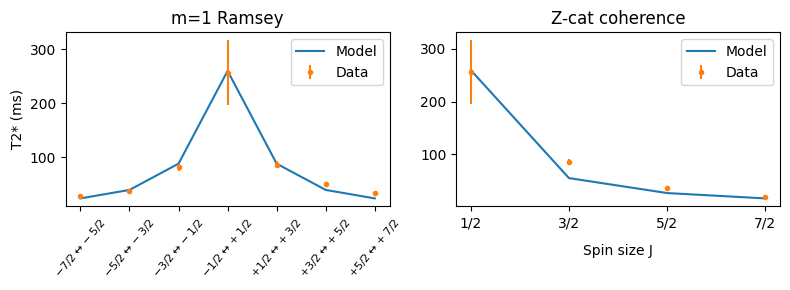

In [126]:
fig, ax = plt.subplots(1,2,figsize=(8, 3))
ax[0].plot(np.arange(7), T2_model, label='Model')
ax[0].errorbar(np.arange(7), T2_data*1e3, T2s_err, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 8, rotation=50)
ax[0].set_title('m=1 Ramsey')
ax[0].legend()

plt.plot(np.array([2, 4, 6, 8])/2-0.5, T2_sim, label='Model')
plt.errorbar(np.array([2, 4, 6, 8])/2-0.5, np.flip(T2_z_data)*1e3, np.flip(T2_z_err)*1e3, marker='.', label='Data', ls='None')
plt.xlabel('Spin size J', labelpad=10)
ax[1].set_xticks([0.5, 1.5, 2.5, 3.5])
ax[1].set_xticklabels(['1/2', '3/2', '5/2', '7/2'])
ax[0].set_ylabel('T2* (ms)')
plt.title('Z-cat coherence')
plt.tight_layout()
plt.legend()
plt.savefig("coherence_model_fit.png", dpi=1200)
plt.savefig("coherence_model_fit.svg", dpi=1200)

# x(y)-cat decay phase dependence

In [916]:
even_parity = (qt.fock_dm(8,0) + qt.fock_dm(8,2) + qt.fock_dm(8,4) + qt.fock_dm(8,6))
odd_parity = (qt.fock_dm(8,1) + qt.fock_dm(8,3) + qt.fock_dm(8,5) + qt.fock_dm(8,7))
parity_op = even_parity - odd_parity

In [917]:
parity_op

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [ ]:
ny = np.array([0, 1, 0])
nx = np.array([1, 0, 0])
thetas = np.linspace(0, np.pi * 2, 50)
fidelity = np.zeros([len(thetas), len(psi0s), len(times)], dtype=float)
T2s = np.zeros([len(thetas), len(psi0s)])
alphas = np.zeros([len(thetas), len(psi0s)])
parity = np.zeros([len(thetas), len(psi0s)])

for t, theta in enumerate(thetas):
    psi0s = [
        qt.Qobj(subspace_rotation_operator(3/2, np.pi/2, ny)) * (qt.basis(8, 2) + np.exp(1j * theta) * qt.basis(8, 5)).unit(),
        qt.Qobj(subspace_rotation_operator(5/2, np.pi/2, ny)) * (qt.basis(8, 1) + np.exp(1j * theta) * qt.basis(8, 6)).unit(),
        qt.Qobj(subspace_rotation_operator(7/2, np.pi/2, ny)) * (qt.basis(8, 0) + np.exp(1j * theta) * qt.basis(8, 7)).unit(),
    ]

    fidelity[t], T2s[t], alphas[t] = run_free_decay(psi0s, times, c_ops)
    for p, psi0 in enumerate(psi0s):
        parity[t, p] = qt.expect(parity_op, psi0 * psi0.dag())

Text(0.5, 0, '$\\varphi$ ($\\pi$)')

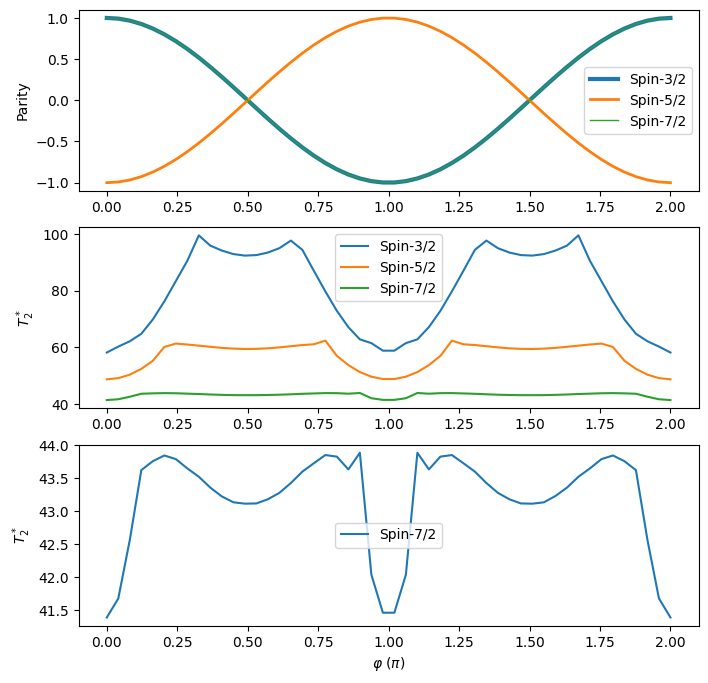

In [934]:
fig, ax = plt.subplots(3,1, figsize=(8, 8), dpi=100)

labels = ['Spin-3/2', 'Spin-5/2', 'Spin-7/2']

for i in range(len(psi0s)):
    ax[0].plot(thetas/np.pi, parity[:, i], label=labels[i], lw=3-i)

for i in range(len(psi0s)):
    ax[1].plot(thetas/np.pi, T2s[:, i]*1e3, label=labels[i])

ax[0].legend()
ax[1].legend()

ax[2].plot(thetas/np.pi, T2s[:, 2]*1e3, label='Spin-7/2')
ax[2].legend()

ax[0].set_ylabel('Parity')
ax[1].set_ylabel(r'$T_2^*$')
ax[2].set_ylabel(r'$T_2^*$')

ax[2].set_xlabel(r'$\varphi$ ($\pi$)')

Text(0.5, 1.0, 'x-cat')

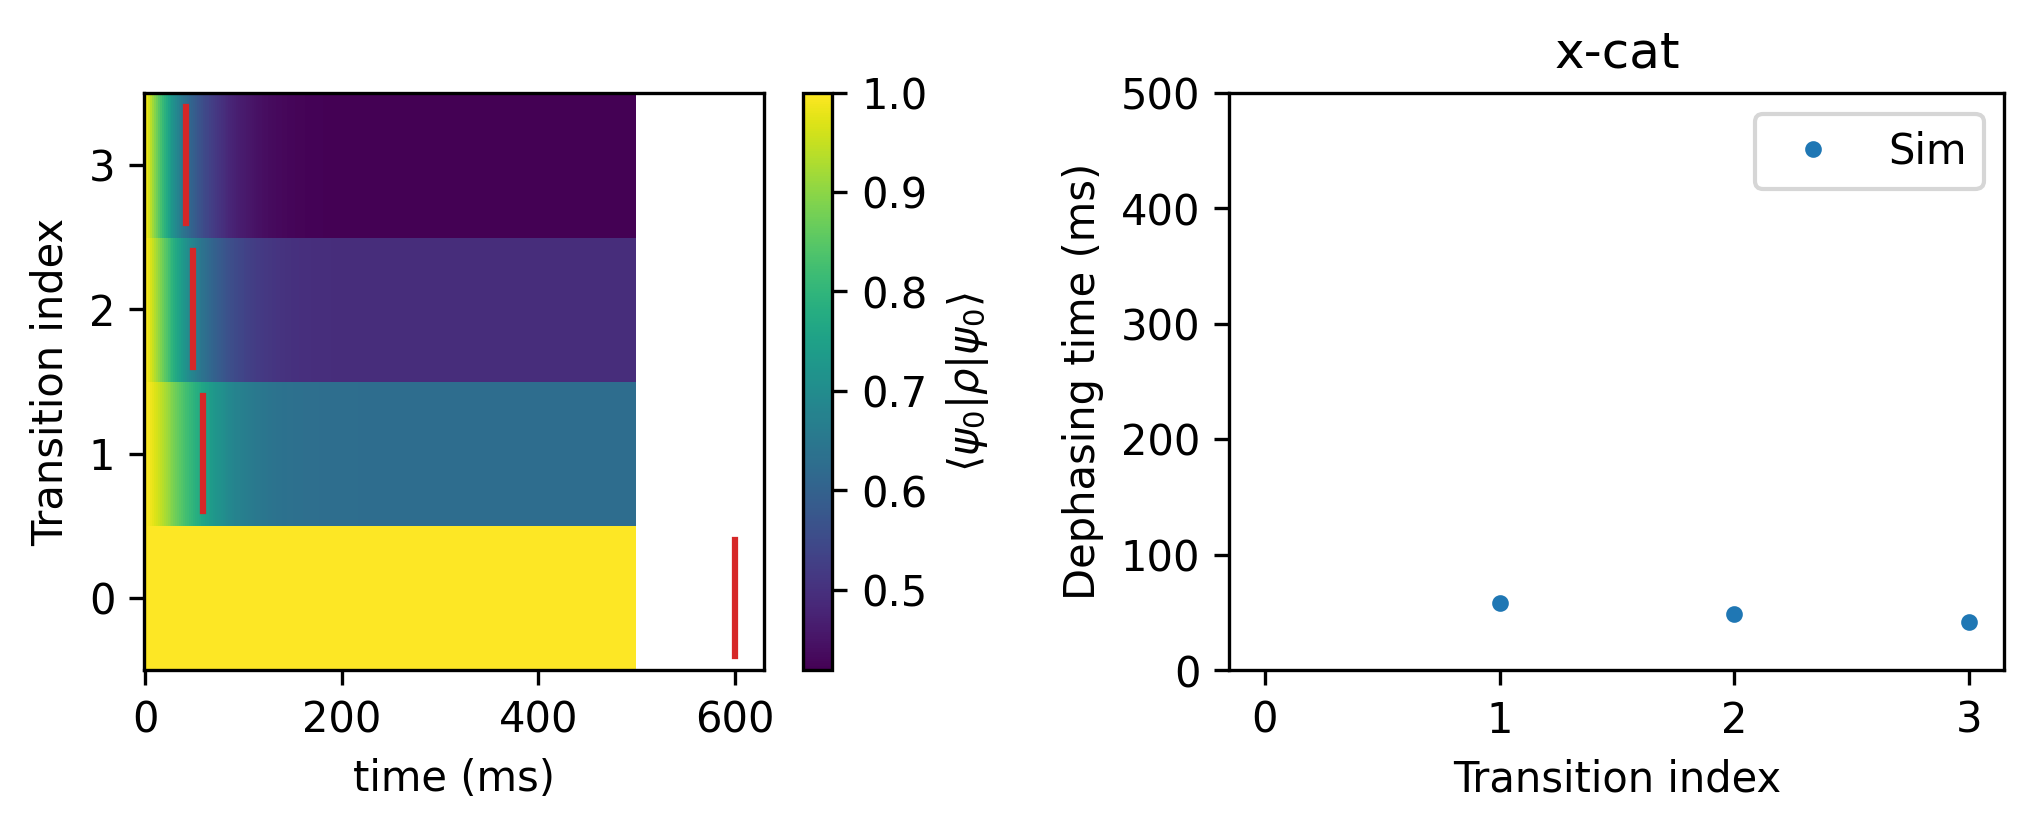

In [869]:
T2s_xdata = np.flip(np.array([46.19, 107.7, 150.8, 233]))*1e-3

plot_free_decay(fidelity, T2s)
plt.title('x-cat')